# 53 Boost Rent — XGBoost optimizado exclusivamente para alquiler

## Objetivos
- **Dataset**: solo `final_rent_idealistaAPI.csv` (754 filas vs 2694 de sale)
- **Outliers vacacionales**: detección y eliminación de alquileres turísticos por `precio_m2` anómalamente alto
- **Limpieza IQR×1.5** sobre `log_precio` (más estricto que IQR×3 usado en modelos anteriores)
- **Target engineering**: comparar `log_precio` vs `log_precio_m2` como target
- **Optuna** (100 trials, CV-RMSE) para búsqueda de hiperparámetros específica de rent

### Nota sobre features ausentes
El gold no incluye distancia a hospitales, universidades ni transporte público.  
Son las variables con mayor potencial de mejora — incorporarlas en el pipeline de transformaciones sería el siguiente salto.

### Leakage evitado
`rentabilidad_bruta_zona` fue descartada — usaba `precio` (= exp(log_precio)) directamente como feature, lo que hacía que el modelo pudiera reconstruir el target casi perfectamente y disparaba el R² artificialmente a >0.9.

In [43]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ──────────────────────────────────────────────────────────────
RANDOM_STATE     = 42
TEST_SIZE        = 0.20
CV_FOLDS         = 5
IQR_FACTOR       = 1.5       # más estricto que IQR×3 de modelos anteriores
MIN_MUNI_OBS     = 10
OPTUNA_TRIALS    = 100
PRECIO_M2_VACACIONAL_UMBRAL = 18.0  # €/m²/mes — por encima se considera vacacional

# ── Rutas ──────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RENT_PATH    = PROJECT_ROOT / "data" / "gold" / "final_rent_idealistaAPI.csv"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Dataset rent: {RENT_PATH}")

Proyecto: /Users/sitomachucas/Documents/BezanillaSL
Dataset rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent_idealistaAPI.csv


## 1. Carga y exploración inicial

In [44]:
df_raw = pd.read_csv(RENT_PATH)
print(f"Filas totales: {len(df_raw)}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"\nNulos por columna:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print(f"\nEstadísticas precio_m2 (€/m²/mes):")
print(df_raw["precio_m2"].describe().round(2))

Filas totales: 754
Columnas: 50

Nulos por columna:
planta          147
distrito        137
subtipologia    644
dtype: int64

Estadísticas precio_m2 (€/m²/mes):
count    754.00
mean      12.52
std        4.04
min        4.52
25%       10.00
50%       11.87
75%       14.17
max       30.00
Name: precio_m2, dtype: float64


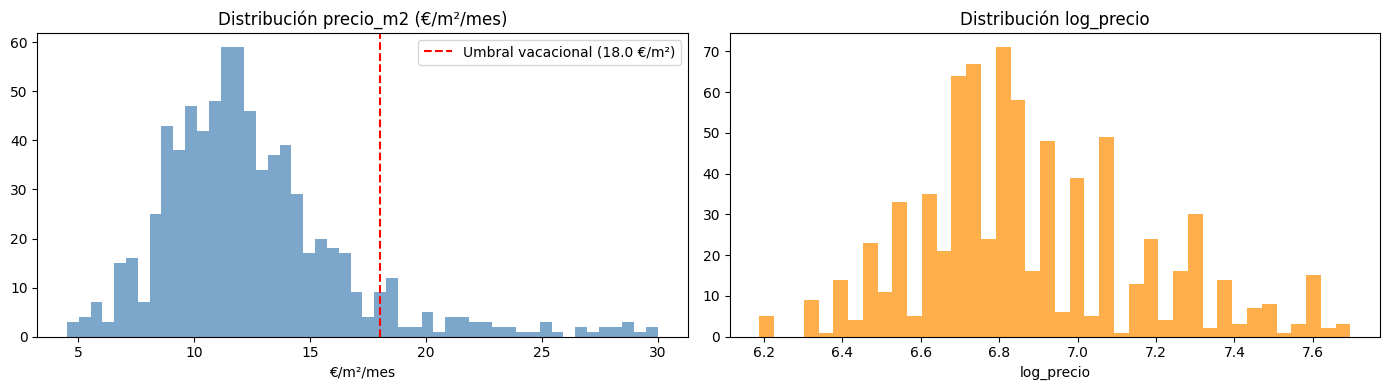

Posibles alquileres vacacionales (precio_m2 > 18.0): 61 / 754 (8.1%)


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw["precio_m2"].dropna(), bins=50, color="steelblue", alpha=0.7)
axes[0].axvline(PRECIO_M2_VACACIONAL_UMBRAL, color="red", linestyle="--",
                label=f"Umbral vacacional ({PRECIO_M2_VACACIONAL_UMBRAL} €/m²)")
axes[0].set_title("Distribución precio_m2 (€/m²/mes)")
axes[0].set_xlabel("€/m²/mes")
axes[0].legend()

axes[1].hist(df_raw["log_precio"].dropna(), bins=40, color="darkorange", alpha=0.7)
axes[1].set_title("Distribución log_precio")
axes[1].set_xlabel("log_precio")

plt.tight_layout()
plt.show()

n_vacacionales = (df_raw["precio_m2"] > PRECIO_M2_VACACIONAL_UMBRAL).sum()
print(f"Posibles alquileres vacacionales (precio_m2 > {PRECIO_M2_VACACIONAL_UMBRAL}): {n_vacacionales} / {len(df_raw)} ({n_vacacionales/len(df_raw)*100:.1f}%)")

## 2. Limpieza de outliers

Dos pasos:
1. **Vacacionales**: eliminar filas con `precio_m2 > umbral` (alquileres turísticos que distorsionan el modelo)
2. **IQR×1.5** sobre `log_precio`: más estricto que el IQR×3 usado en otros notebooks

In [46]:
df = df_raw[df_raw["log_precio"].notna() & df_raw["precio_m2"].notna()].copy()
print(f"Filas con log_precio y precio_m2 válidos: {len(df)}")

# ── Paso 1: eliminar vacacionales ─────────────────────────────────────────────
mask_vacacional = df["precio_m2"] <= PRECIO_M2_VACACIONAL_UMBRAL
print(f"\nPaso 1 — Vacacionales eliminados: {(~mask_vacacional).sum()} ({(~mask_vacacional).mean()*100:.1f}%)")
df = df[mask_vacacional].copy()

# ── Paso 2: IQR×1.5 sobre log_precio ─────────────────────────────────────────
q1, q3 = df["log_precio"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr
mask_iqr = df["log_precio"].between(lo, hi)
print(f"Paso 2 — IQR×{IQR_FACTOR} eliminados: {(~mask_iqr).sum()} ({(~mask_iqr).mean()*100:.1f}%)")
print(f"  Rango válido log_precio: [{lo:.3f}, {hi:.3f}]  →  precio [{np.exp(lo):.0f} €, {np.exp(hi):.0f} €]")
df = df[mask_iqr].copy()

print(f"\nFilas finales para modelar: {len(df)}")
print(f"precio_m2 stats tras limpieza:")
print(df["precio_m2"].describe().round(2))

Filas con log_precio y precio_m2 válidos: 754

Paso 1 — Vacacionales eliminados: 61 (8.1%)
Paso 2 — IQR×1.5 eliminados: 19 (2.7%)
  Rango válido log_precio: [6.207, 7.481]  →  precio [496 €, 1774 €]

Filas finales para modelar: 674
precio_m2 stats tras limpieza:
count    674.00
mean      11.57
std        2.64
min        4.52
25%        9.79
50%       11.48
75%       13.37
max       18.00
Name: precio_m2, dtype: float64


## 3. Target alternativo

- `log_precio_m2`: log(precio/m²) — normaliza por superficie antes de que el modelo lo aprenda

> **Advertencia eliminada**: `rentabilidad_bruta_zona` fue descartada — usaba `precio` directamente (= exp(target)), causando data leakage que disparaba el R² artificialmente a >0.9.

In [47]:
# Target alternativo: log(precio/m²) — solo para usarlo como TARGET, nunca como feature
# IMPORTANTE: precio_m2, precio, log_precio_m2 no entran en X — son derivados del target
df["log_precio_m2"] = np.log(df["precio"] / df["superficie_construida_m2"].clip(lower=1))

print("Target alternativo disponible:")
print(f"  log_precio_m2 — media: {df['log_precio_m2'].mean():.4f}  std: {df['log_precio_m2'].std():.4f}")
print(f"  log_precio    — media: {df['log_precio'].mean():.4f}  std: {df['log_precio'].std():.4f}")

Target alternativo disponible:
  log_precio_m2 — media: 2.4209  std: 0.2424
  log_precio    — media: 6.8371  std: 0.2475


## 4. Selección de target

Comparamos `log_precio` vs `log_precio_m2` como target.
El modelo final usará el que mejor CV-RMSE dé en Optuna.

In [48]:
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "planta_num",
    "es_exterior_piso",
    "tiene_ascensor_piso",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",      # precio medio de VENTA por municipio — no deriva del target
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
    # EXCLUIDAS por leakage: precio, precio_m2, precio_m2_raw, log_precio, log_precio_m2, rentabilidad_bruta_zona
]

def build_X(df: pd.DataFrame) -> tuple:
    """Construye X con BASE_FEATURES + municipio_* OHE agrupando municipios con pocas obs."""
    df2 = df.copy()

    base = [f for f in BASE_FEATURES if f in df2.columns]

    mun_cols = sorted([c for c in df2.columns if c.startswith("municipio_")])
    if mun_cols:
        counts = df2[mun_cols].sum()
        small  = counts[counts < MIN_MUNI_OBS].index.tolist()
        if small:
            df2["municipio_otros"] = df2[small].max(axis=1)
            df2 = df2.drop(columns=small)
        mun_final = sorted(c for c in df2.columns if c.startswith("municipio_"))
    else:
        mun_final = []

    all_feats = base + [m for m in mun_final if m not in base]
    X = df2[all_feats].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X, all_feats


def get_metrics(y_real, y_pred, target_name="log_precio") -> pd.DataFrame:
    mse = mean_squared_error(y_real, y_pred)
    return pd.DataFrame({
        "target": [target_name],
        "MSE":  [round(float(mse), 5)],
        "RMSE": [round(float(np.sqrt(mse)), 5)],
        "MAE":  [round(float(mean_absolute_error(y_real, y_pred)), 5)],
        "R2":   [round(float(r2_score(y_real, y_pred)), 5)],
        "MAPE": [round(float(mean_absolute_percentage_error(y_real, y_pred)), 5)],
    })


X, feats = build_X(df)
print(f"Features ({len(feats)}) — sin ninguna derivada del precio:")
print(feats)

Features (28) — sin ninguna derivada del precio:
['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_El Astillero', 'municipio_Piélagos', 'municipio_Santander', 'municipio_Suances', 'municipio_Torrelavega', 'municipio_otro', 'municipio_otros']


## 5. Comparación rápida de targets

XGBoost base (sin tuning) con `log_precio` vs `log_precio_m2` para decidir cuál usar en Optuna.

In [49]:
BASE_XGB = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                reg_lambda=3, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results_target = []

for target_col in ["log_precio", "log_precio_m2"]:
    y = df[target_col].values
    cv = cross_val_score(
        XGBRegressor(**BASE_XGB), X, y,
        cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    cv_r2 = cross_val_score(
        XGBRegressor(**BASE_XGB), X, y,
        cv=kf, scoring="r2", n_jobs=-1
    )
    results_target.append({
        "target": target_col,
        "CV_RMSE": round(float(-cv.mean()), 5),
        "CV_R2":   round(float(cv_r2.mean()), 5),
    })
    print(f"  {target_col}: CV-RMSE={-cv.mean():.5f}  CV-R²={cv_r2.mean():.5f}")

df_target_cmp = pd.DataFrame(results_target)
print(f"\n{df_target_cmp.to_string(index=False)}")

# Seleccionar el mejor target para Optuna
best_target = df_target_cmp.loc[df_target_cmp["CV_R2"].idxmax(), "target"]
print(f"\n>>> Target seleccionado para Optuna: {best_target}")
TARGET_COL = best_target
y_all = df[TARGET_COL].values

  log_precio: CV-RMSE=0.15001  CV-R²=0.62442
  log_precio_m2: CV-RMSE=0.14945  CV-R²=0.61519

       target  CV_RMSE   CV_R2
   log_precio  0.15001 0.62442
log_precio_m2  0.14945 0.61519

>>> Target seleccionado para Optuna: log_precio


## 6. Split train / test

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {X.shape[1]}")

Train: 539 | Test: 135 | Features: 28


## 7. Búsqueda de hiperparámetros con Optuna

Objetivo: minimizar CV-RMSE (5-fold) sobre el conjunto de train.  
El test **no se toca** durante la búsqueda.

In [51]:
def objective(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 200, 1000, step=50),
        max_depth         = trial.suggest_int("max_depth", 3, 7),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 15),
        reg_lambda        = trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        gamma             = trial.suggest_float("gamma", 0.0, 5.0),
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbosity         = 0,
    )
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv = cross_val_score(
        XGBRegressor(**params), X_train, y_train,
        cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    return float(-cv.mean())


study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print(f"\nMejor CV-RMSE: {study.best_value:.5f}")
print("Mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 46. Best value: 0.148844: 100%|██████████| 100/100 [00:34<00:00,  2.87it/s]


Mejor CV-RMSE: 0.14884
Mejores hiperparámetros:
  n_estimators: 300
  max_depth: 3
  learning_rate: 0.02718778221572684
  subsample: 0.8716671434851786
  colsample_bytree: 0.849217213125098
  min_child_weight: 12
  reg_lambda: 3.339635697528345
  reg_alpha: 0.12575291550179832
  gamma: 0.0046837673134361825


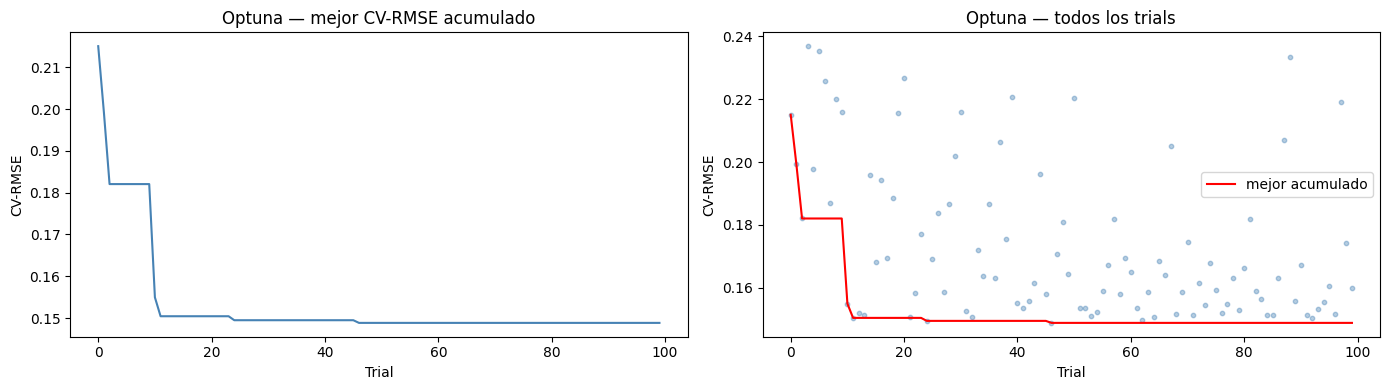

In [52]:
# Curva de convergencia de Optuna
trial_values = [t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummin()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(best_so_far, color="steelblue")
axes[0].set_title("Optuna — mejor CV-RMSE acumulado")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV-RMSE")

axes[1].scatter(range(len(trial_values)), trial_values, alpha=0.4, s=10, color="steelblue")
axes[1].plot(best_so_far, color="red", linewidth=1.5, label="mejor acumulado")
axes[1].set_title("Optuna — todos los trials")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("CV-RMSE")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Modelo final con mejores hiperparámetros

In [53]:
BEST_PARAMS = {**study.best_params, "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0}

model = XGBRegressor(**BEST_PARAMS)
model.fit(X_train, y_train)

# CV final sobre train
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_rmse = float(-cross_val_score(
    XGBRegressor(**BEST_PARAMS), X_train, y_train,
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
).mean())

m_train = get_metrics(y_train, model.predict(X_train), TARGET_COL)
m_test  = get_metrics(y_test,  model.predict(X_test),  TARGET_COL)

summary = pd.concat([
    m_train.assign(split="train"),
    pd.DataFrame({"target": [TARGET_COL], "split": ["CV"], "MSE": [None],
                  "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
    m_test.assign(split="test"),
], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]

print(f"Target: {TARGET_COL}")
print(f"\n{summary.to_string(index=False)}")

delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
print(f"\nSobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R²: {delta_r2:.4f}")

Target: log_precio

split     MSE    RMSE     MAE      R2    MAPE
train 0.01141 0.10684 0.08269 0.81024 0.01208
   CV     NaN 0.14884     NaN     NaN     NaN
 test 0.02404 0.15505 0.11983 0.63093 0.01748

Sobreajuste → ratio RMSE test/train: 1.4512 | delta R²: 0.1793


## 9. Diagnósticos

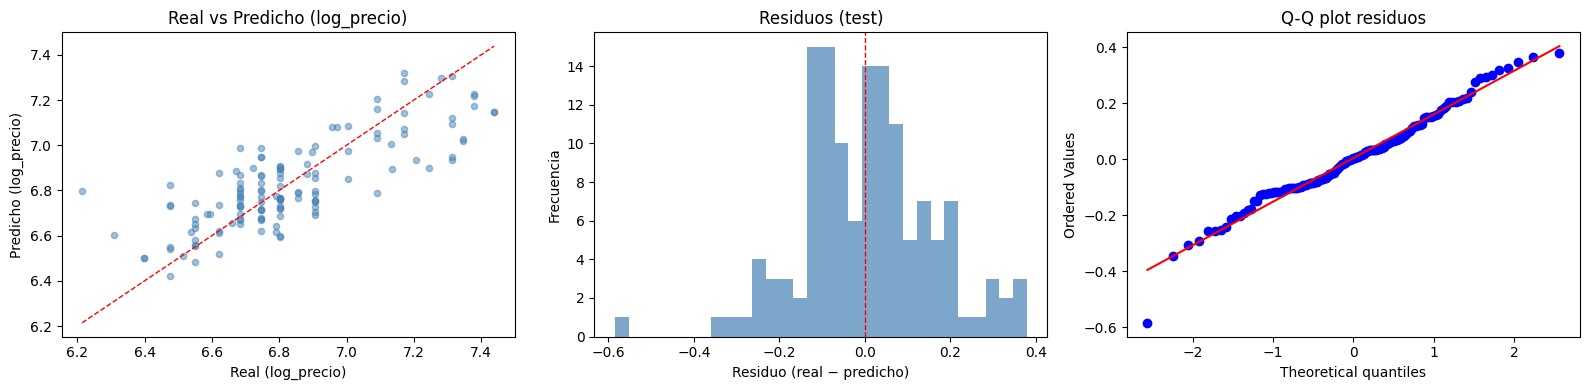

In [54]:
pred_test  = model.predict(X_test)
pred_train = model.predict(X_train)
residuals  = y_test - pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.scatter(y_test, pred_test, alpha=0.5, s=20, color="steelblue")
lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax.plot(lim, lim, "r--", linewidth=1)
ax.set_title(f"Real vs Predicho ({TARGET_COL})")
ax.set_xlabel(f"Real ({TARGET_COL})")
ax.set_ylabel(f"Predicho ({TARGET_COL})")

ax = axes[1]
ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Residuos (test)")
ax.set_xlabel("Residuo (real − predicho)")
ax.set_ylabel("Frecuencia")

ax = axes[2]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot residuos")

plt.tight_layout()
plt.show()

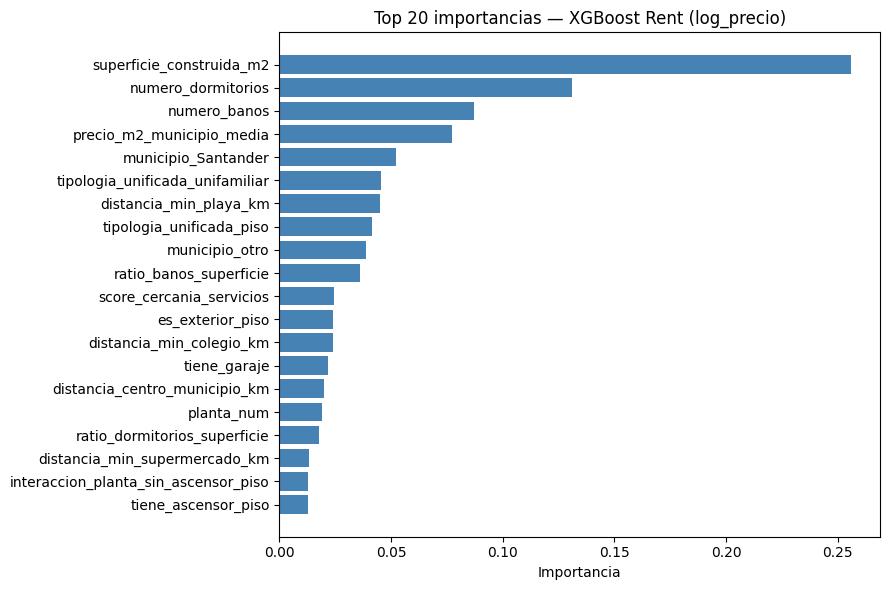

                             feature  importance
            superficie_construida_m2    0.256155
                  numero_dormitorios    0.131108
                        numero_banos    0.087164
           precio_m2_municipio_media    0.077327
                 municipio_Santander    0.052080
     tipologia_unificada_unifamiliar    0.045561
              distancia_min_playa_km    0.045156
            tipologia_unificada_piso    0.041543
                      municipio_otro    0.038579
              ratio_banos_superficie    0.035894
            score_cercania_servicios    0.024326
                    es_exterior_piso    0.024193
            distancia_min_colegio_km    0.023761
                        tiene_garaje    0.021720
       distancia_centro_municipio_km    0.020103
                          planta_num    0.019078
        ratio_dormitorios_superficie    0.017678
       distancia_min_supermercado_km    0.013094
interaccion_planta_sin_ascensor_piso    0.012864
                 tie

In [55]:
fi = (
    pd.DataFrame({"feature": feats, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
ax.set_title(f"Top 20 importancias — XGBoost Rent ({TARGET_COL})")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

print(fi.to_string(index=False))

## 10. Resumen y parámetros exportables

In [56]:
print("=" * 80)
print("RESUMEN FINAL — XGBoost Rent")
print("=" * 80)
print(f"  Target         : {TARGET_COL}")
print(f"  Filas tras limpieza: {len(df)}")
print(f"    · Vacacionales eliminados (precio_m2 > {PRECIO_M2_VACACIONAL_UMBRAL}): ver celda 2")
print(f"    · IQR×{IQR_FACTOR} sobre log_precio: ver celda 2")
print(f"  Features       : {len(feats)}")
print(f"  Optuna trials  : {OPTUNA_TRIALS}")
print(f"  CV-RMSE (train): {cv_rmse:.5f}")
print(f"  Test RMSE      : {float(m_test['RMSE'].iloc[0]):.5f}")
print(f"  Test R²        : {float(m_test['R2'].iloc[0]):.5f}")
print()
print("Hiperparámetros óptimos (para copiar a 55_sale_rent_models):")
params_export = {k: v for k, v in BEST_PARAMS.items()
                 if k not in ("random_state", "n_jobs", "verbosity")}
print(f"  XGB_PARAMS_RENT = {params_export}")
print(f"  XGB_FEATURES_RENT = {feats}")
print(f"  TARGET_RENT = '{TARGET_COL}'")

print()
print("Siguiente paso — features de alto impacto potencial no disponibles aún:")
print("  · distancia_min_hospital_km")
print("  · distancia_min_universidad_km")
print("  · distancia_min_parada_bus_km / distancia_min_tren_km")
print("  Añadirlas en el pipeline de transformaciones (04_transformations) podría")
print("  ser el mayor salto de R² disponible sin más datos.")

RESUMEN FINAL — XGBoost Rent
  Target         : log_precio
  Filas tras limpieza: 674
    · Vacacionales eliminados (precio_m2 > 18.0): ver celda 2
    · IQR×1.5 sobre log_precio: ver celda 2
  Features       : 28
  Optuna trials  : 100
  CV-RMSE (train): 0.14884
  Test RMSE      : 0.15505
  Test R²        : 0.63093

Hiperparámetros óptimos (para copiar a 55_sale_rent_models):
  XGB_PARAMS_RENT = {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.02718778221572684, 'subsample': 0.8716671434851786, 'colsample_bytree': 0.849217213125098, 'min_child_weight': 12, 'reg_lambda': 3.339635697528345, 'reg_alpha': 0.12575291550179832, 'gamma': 0.0046837673134361825}
  XGB_FEATURES_RENT = ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'rati